In [2]:
import pandas as pd

from matplotlib import pyplot as plt
import seaborn as sns

import warnings 
warnings.filterwarnings('ignore')

In [3]:
train = pd.read_csv(r"C:\Users\Yuvaraj S\OneDrive\Desktop\16MLP\train.csv")
train

,x,y
0,24.0,21.549452
1,50.0,47.464463
2,15.0,17.218656
3,38.0,36.586398
4,87.0,87.288984
...,...,...
695,58.0,58.595006
696,93.0,94.625094
697,82.0,88.603770
698,66.0,63.648685


In [4]:
train.shape

(700, 2)

In [5]:
train.isna().sum()

x    0
y    1
dtype: int64

In [6]:
train.dropna(inplace = True)

In [7]:
train.isna().sum()

x    0
y    0
dtype: int64

#### Assumption 1: Test for Linearity

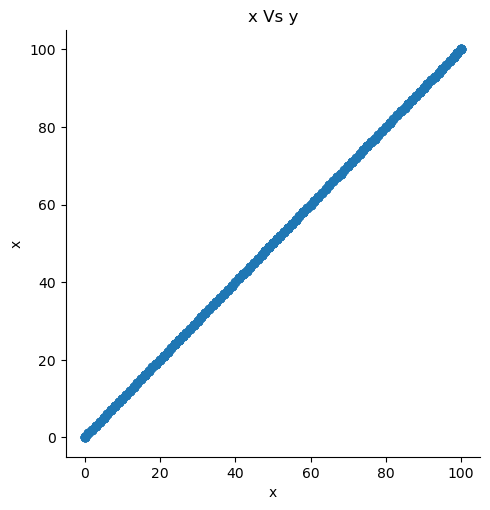

In [8]:
sns.lmplot(x='x',y='x',data=train)
plt.title('x Vs y')
plt.show()

### 2. Test for Normality

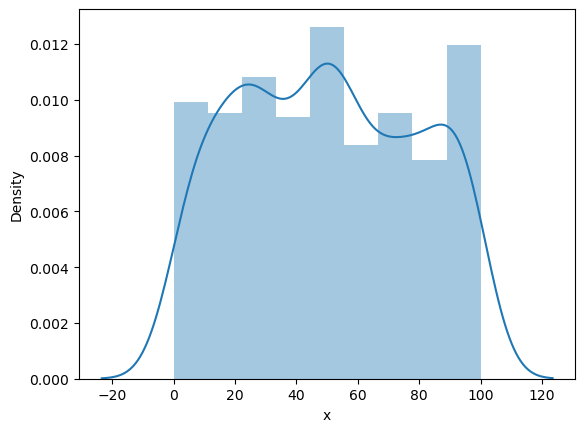

In [8]:
sns.distplot(a=train['x'],hist = True)
plt.show()

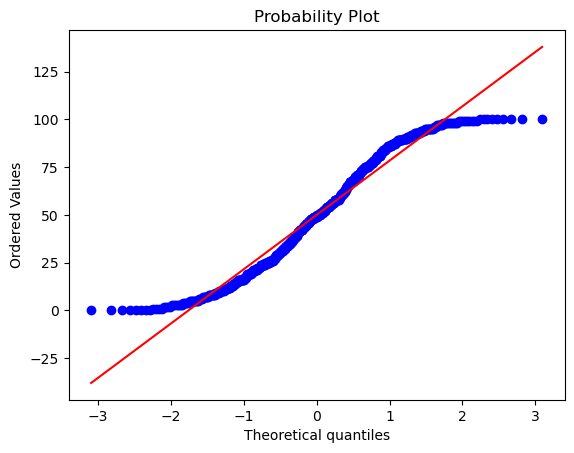

In [9]:
from scipy import stats
stats.probplot(x=train['x'],dist='norm',plot=plt)
plt.show()

#### Model Buliding 

In [10]:
x = train.drop(labels=['y'],axis = 1)
y = train[['y']]

In [11]:
x

,x
0,24.0
1,50.0
2,15.0
3,38.0
4,87.0
...,...
695,58.0
696,93.0
697,82.0
698,66.0


In [12]:
y

,y
0,21.549452
1,47.464463
2,17.218656
3,36.586398
4,87.288984
...,...
695,58.595006
696,94.625094
697,88.603770
698,63.648685


#### Model Training 

In [13]:
from sklearn.linear_model import LinearRegression
linear_model_1 = LinearRegression()
linear_model_1.fit(x,y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [14]:
y_pred = linear_model_1.predict(x)
y_pred


array([[23.9084877 ],
       [49.92555363],
       [14.90258026],
       [37.91767705],
       [86.94983976],
       [35.91636428],
       [11.90061112],
       [80.94590147],
       [24.90914408],
       [ 4.89601644],
       [15.90323665],
       [15.90323665],
       [23.9084877 ],
       [38.91833343],
       [53.92817916],
       [59.93211745],
       [25.90980046],
       [72.94065041],
       [28.91176961],
       [30.91308237],
       [67.9373685 ],
       [86.94983976],
       [57.93080468],
       [53.92817916],
       [83.94787061],
       [57.93080468],
       [48.92489725],
       [19.90586217],
       [89.9518089 ],
       [47.92424086],
       [ 3.89536006],
       [24.90914408],
       [41.92030257],
       [-0.10726546],
       [59.93211745],
       [92.95377805],
       [38.91833343],
       [ 6.89732921],
       [20.90651855],
       [67.9373685 ],
       [83.94787061],
       [-0.10726546],
       [57.93080468],
       [18.90520579],
       [35.91636428],
       [18

In [15]:
from sklearn.metrics import r2_score
r2_score(y,y_pred)

0.9907015319025518

#### Model Evaluation


In [16]:
error = y - y_pred
error

,y
0,-2.359036
1,-2.461091
2,2.316076
3,-1.331279
4,0.339144
...,...
695,0.664202
696,1.671316
697,6.657212
698,-2.287370


# 5. Test for Homoscesdasticity

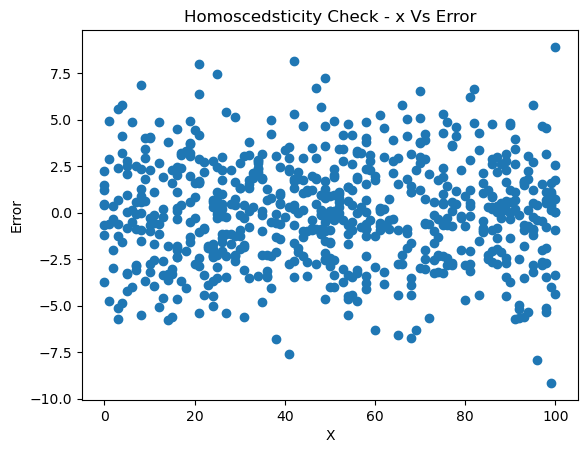

In [17]:
plt.scatter(x = train['x'], y=error)
plt.title('Homoscedsticity Check - x Vs Error')
plt.xlabel('X')
plt.ylabel('Error')
plt.show()

# 6. Test for Zero Residual Mean

In [ ]:
y

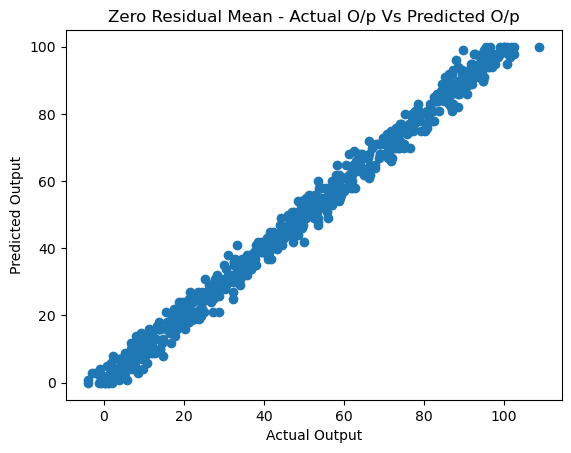

In [18]:
plt.scatter(x = y, y = y_pred)
plt.title('Zero Residual Mean - Actual O/p Vs Predicted O/p')
plt.xlabel('Actual Output')
plt.ylabel('Predicted Output')
plt.show()